<a href="https://colab.research.google.com/github/FunkyDonkey065/Facade_aesthetic_evaluator/blob/main/FAST_AI_ML_test_facade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install packages\
image retrieving funciton

In [10]:
!pip install -U ddgs
!pip install -U fastcore
!pip install -U fastbook
!pip install nbdev
!pip install gdown

from ddgs import DDGS
from fastcore.all import *
from fastbook import *


def search_images(keywords, max_images=200):
  return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 42.8 MB/s eta 0:00:00
  Attempting uninstall: lxml
    Found existing installation: lxml 5.4.0
    Uninstalling lxml-5.4.0:
      Successfully uninstalled lxml-5.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: fastcore
    Found existing installation: fastcore 1.8.13
    Uninstalling fastcore-1.8.13:
      Successfully uninstalled fastcore-1.8.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 5.7 MB/s eta 0:00:00


Test search

In [11]:
urls = search_images('good building exterior', max_images=2)
urls[1]

'https://www.build-review.com/wp-content/uploads/2022/12/AdobeStock_521077579-1.jpg'

download the image according to the url (beautiful facade)




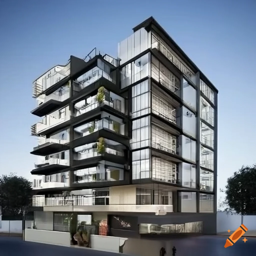

In [12]:
from fastdownload import download_url
dest = 'images_test1.jpg'
download_url(urls[0], dest, show_progress=False)

im = Image.open(dest)
im.to_thumb(256,256)


download the image according to the url (ugly facade)

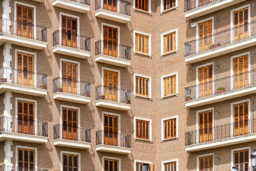

In [13]:
download_url(search_images('common building exterior', max_images=1)[0], 'images_test2.jpg', show_progress=False)
im = Image.open('images_test2.jpg')
im.to_thumb(256,256)

Formal search

In [14]:
facade_types = 'good building exterior', 'bad building exterior', 'common building exterior'
path = Path('facade')

for o in facade_types:
  dest = (path/o)
  dest.mkdir(exist_ok=True, parents=True)
  download_images(dest, urls=search_images(f'{facade_types}', max_images=100))



# Train the model

remove the failed url download attempts

In [15]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

construct model data structure and determine the process method

In [16]:
??RandomResizedCrop

augment the image by randomcrop

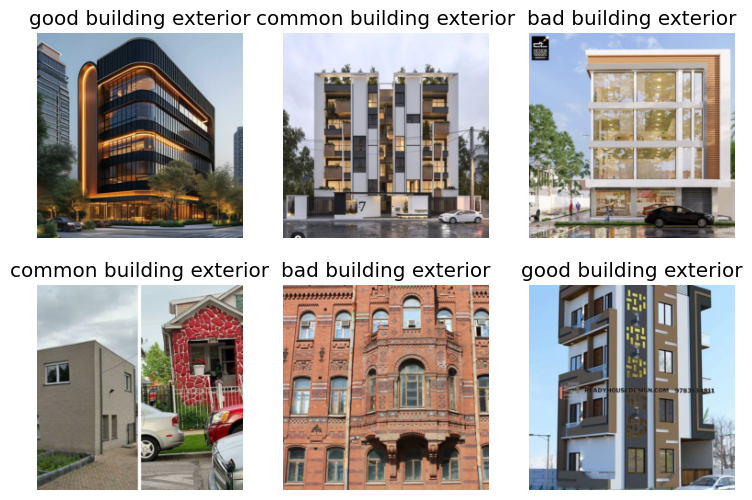

In [17]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(224, ResizeMethod.Crop)).dataloaders(path)

dls.train.show_batch(max_n=6, nrows=2)

In [77]:
#| default_exp FAST_AI_ML_test_facade

In [18]:
#|export
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 336MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.848842,1.760026,0.706897,00:44


epoch,train_loss,valid_loss,error_rate,time
0,2.166638,1.967802,0.793103,00:53


Confusion matrix to see the error

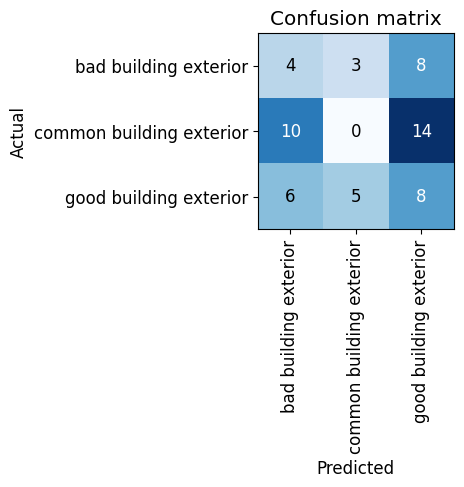

In [19]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

show the top losses

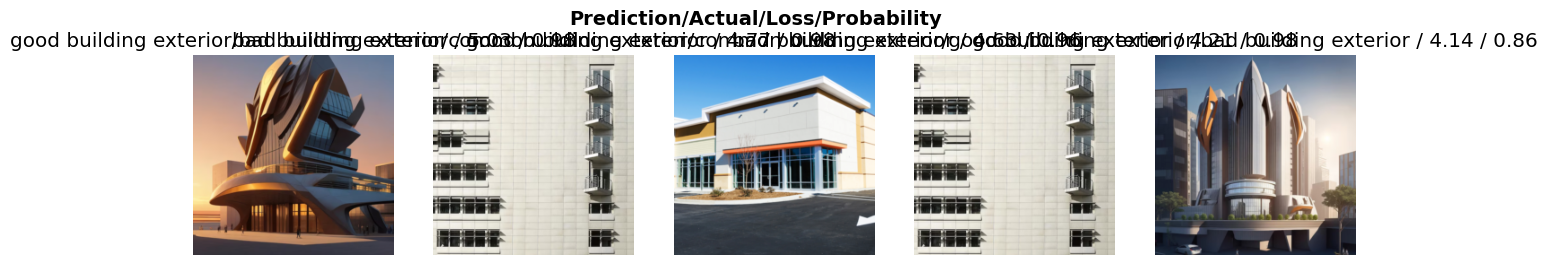

In [20]:
interp.plot_top_losses(5, nrows=1)

use data cleaner

In [21]:
from fastai.vision.widgets import *
cleaner = ImageClassifierCleaner(learn)
cleaner
for idx in cleaner.delete(): cleaner.fns[idx].unlink()
for idx,cat in cleaner.change(): shutil.move(str(cleaner.fns[idx]), path/cat)

KeyboardInterrupt: 

test its ability of recognizing beautiful facades

In [ ]:
is_good,_,probs = learn.predict(PILImage.create('images_test2.jpg'))
print(f"This is a: {is_good}.")
print(f"Probability it's a good facade: {probs[0]:.4f}")
#

In [ ]:
learn.export('facade_prediction.pkl')

##Export local

In [67]:
import gradio as gr

In [65]:
#|export
categories = ('good', 'bad', 'common')

def classify_image(img):
    pred,idx,probs = learn.predict(img)
    return dict(zip(categories, map(float,probs)))

In [68]:
#|export
image = gr.Image()
label = gr.Label()
examples = ['images_test1.jpg', 'images_test2.jpg']

intf = gr.Interface(fn=classify_image, inputs=image, outputs=label, examples=examples)
intf.launch(inline=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1cd792d3905377afc5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


get the flag

In [ ]:
import pandas as pd
import os

flagged_dir = 'flagged'
flagged_csv_path = os.path.join(flagged_dir, 'log.csv')

if os.path.exists(flagged_csv_path):
    flagged_df = pd.read_csv(flagged_csv_path)
    display(flagged_df)
else:
    print(f"No flagged data found yet. Flag some examples in the Gradio interface first. Looking for: {flagged_csv_path}")

#Export public

In [ ]:
!pwd

In [43]:
from google.colab import auth
auth.authenticate_user()

# Then use gdown or other methods to download specific files

# Download specific files by ID instead of mounting

In [ ]:
from google.colab import drive
drive.mount('/content/drive1')

In [44]:
#hide, try to download it from the drive, failed, always broken file
#update, not broken file, but html return error message
import gdown

file_id = "1sv6ABWXu7hOE6UVhv6l9ZyPg9N32tKBI#scrollTo=zDCjAciKV7bz"
url = f"https://drive.google.com/drive/folders/{file_id}"
#url = 'https://colab.research.google.com/drive/1sv6ABWXu7hOE6UVhv6l9ZyPg9N32tKBI?usp=drive_link'
output = "facade_evaluator.ipynb"  # or whatever filename you want
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/drive/folders/1sv6ABWXu7hOE6UVhv6l9ZyPg9N32tKBI#scrollTo=zDCjAciKV7bz
To: /content/facade_evaluator.ipynb
1.13MB [00:00, 10.4MB/s]


'facade_evaluator.ipynb'

In [104]:
from google.colab import files
uploaded = files.upload()


Saving FAST_AI_ML_test_facade.ipynb to FAST_AI_ML_test_facade.ipynb


In [103]:
!head -n 20 FAST_AI_ML_test_facade.ipynb

{
  "nbformat": 4,
  "nbformat_minor": 0,
  "metadata": {
    "colab": {
      "provenance": []
    },
    "kernelspec": {
      "name": "python3",
      "display_name": "Python 3"
    },
    "language_info": {
      "name": "python"
    }
  },
  "cells": [
    {
      "cell_type": "markdown",
      "source": [
        "Install packages\\\n",


In [105]:

import nbdev
#print(nbdev.__version__)
nbdev.export.nb_export('FAST_AI_ML_test_facade.ipynb')